In [25]:
import joblib              as jlb
import matplotlib.pyplot   as plt
import pandas as pd
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')
    
from collections           import Counter
from sklearn.decomposition import PCA
from kneed import KneeLocator
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from pyclustering.utils import timedcall
from data_processing import D

In [26]:
#class PAM
import numpy as np
class PAM:
    def __init__(self,data,n_clusters = 5):
        self.n_clusters        = n_clusters
        self.data              = data
    def _euclid_dist(self, a, b):
        return np.linalg.norm(a - b,axis=2)
    def assign_clusters(self,points, medoids):
        distances=self._euclid_dist(points[:,np.newaxis],medoids)
        labels=np.argmin(distances,axis=1)
        return labels
    def fit(self):
        X=self.data.values
        random_idx=np.random.choice(len(X),self.n_clusters,replace=False)
        medoids=X[random_idx]

        #lần gán nhãn đầu tiên
        labels=self.assign_clusters(X,medoids)
        new_medoids=[]

        for i in range(self.n_clusters):
            clusters_points=X[labels==i]

            if len(clusters_points)==0:
                new_medoids.append(medoids[i])
                continue
            costs=[]

            for candidate in clusters_points:
                cost=np.sum(np.linalg.norm(clusters_points-candidate,axis=1))
                costs.append(cost)
            best_medoids=clusters_points[np.argmin(costs)]
            new_medoids.append(best_medoids)
        new_medoids=np.array(new_medoids)

        self.medoids_=new_medoids
        self.labels_=labels
        self.Inertia=np.sum(np.linalg.norm(X - self.medoids_[self.labels_], axis=1))
    def get_medoids(self):
        return self.medoids_
    def get_labels(self):
        return self.labels_
    def get_Inertia(self):
        return self.Inertia
    

#pam fast build
def PAM_silhouette_analysis(data, k_range,print_scores=False):
    silhouette_scores = []
    for k in k_range:
        model = PAM(data,n_clusters=k)
        model.fit()
        #PAM get labels

        silhouette_scores.append(silhouette_score(data, model.get_labels()))
        if print_scores:
            print(f'k={k}, Silhouette Score: {silhouette_score(data, model.get_labels()):.4f}')

    plt.figure(figsize=(8, 5))
    plt.plot(k_range, silhouette_scores, marker='o')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Analysis for PAM')
    plt.show()
def PAM_davies_bouldin_analysis(data, k_range,print_scores=False):
    davies_bouldin_scores = []
    for k in k_range:
        model = PAM(data,n_clusters=k)
        model.fit()
        davies_bouldin_scores.append(davies_bouldin_score(data, model.get_labels()))
        if print_scores:
            print(f'k={k}, Davies-Bouldin Score: {davies_bouldin_score(data, model.get_labels()):.4f}')

    plt.figure(figsize=(8, 5))
    plt.plot(k_range, davies_bouldin_scores, marker='o')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Davies-Bouldin Score')
    plt.title('Davies-Bouldin Analysis for PAM')
    plt.show()
def PAM_Inertia_analysis(data, k_range,print_scores=False):
    inertia_scores = []
    k_values=k_range
    for k in k_range:
        model = PAM(data,n_clusters=k)
        model.fit()
        inertia_scores.append(model.get_Inertia())
        if print_scores:
            print(f'k={k}, Inertia: {model.get_Inertia():.4f}')
    kneedle=KneeLocator(k_values,inertia_scores,curve='convex',direction='decreasing')
    k_optimal=kneedle.knee

    plt.figure(figsize=(8, 5))
    plt.plot(k_range, inertia_scores, marker='o')
    plt.axvline(x=k_optimal, linestyle='--')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia')
    plt.title('Inertia Analysis for PAM')
    plt.show()

Tiền xử lý dữ liệu

In [27]:
features=['Age','Income','Education'
                ,'Family_Size','Total_Spend'
                ,'Wines','Food','Gold'
                ,'Wines_ratio','Food_ratio','Gold_ratio'
                ,'NumWebPurchases'
                ,'NumDealsPurchases','NumCatalogPurchases'
                ,'NumStorePurchases','NumWebVisitsMonth']
data=D[features].copy()
print(data.shape)
print(data.head(1))

(2229, 16)
        Age    Income  Education  Family_Size  Total_Spend     Wines  \
0  1.015715  0.316484  -0.893147    -1.759459     1.204332  0.985094   

       Food      Gold  Wines_ratio  Food_ratio  Gold_ratio  NumWebPurchases  \
0  1.420852  1.060908    -0.212241    0.713606   -0.618688         1.405471   

   NumDealsPurchases  NumCatalogPurchases  NumStorePurchases  \
0           0.358938             2.633984           -0.55916   

   NumWebVisitsMonth  
0            0.68992  


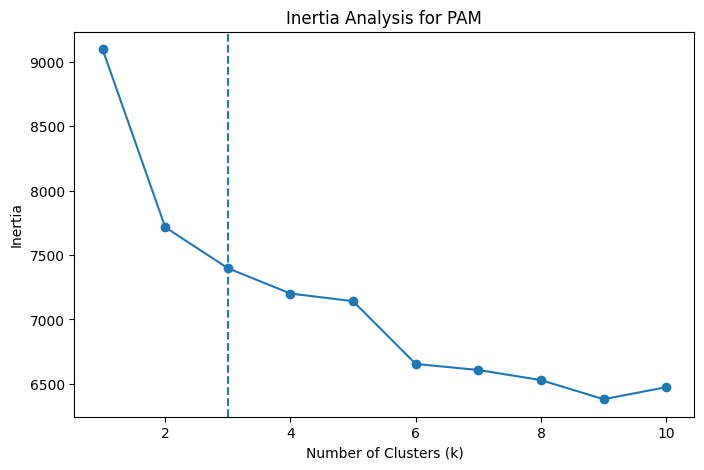

In [28]:
PAM_Inertia_analysis(data, range(1, 11))

Xây dựng mô hình PAM

In [29]:
k=3
Pam_model=PAM(data,n_clusters = k)
(ticks,results) = timedcall(Pam_model.fit)
print(f'PAM clustering completed in {ticks:.4f} seconds.')

PAM clustering completed in 0.1441 seconds.


In [30]:
## Lưu trữ mô hình để khai thác về sau
jlb.dump(Pam_model, '../customer_clustering/Output/PAM.mdl')

['../customer_clustering/Output/PAM.mdl']

In [31]:
## Khai thác mô hình đã được xây dựng
saved=jlb.load('../customer_clustering/Output/PAM.mdl')

In [32]:
## Kết quả gom cụm khách hàng
data['cluster'] = saved.get_labels()

print('\nKích thước các clusters:', Counter(data['cluster']))
print('\n2 clusters lớn nhất:',    Counter(data['cluster']).most_common(2))


Kích thước các clusters: Counter({0: 1159, 2: 849, 1: 221})

2 clusters lớn nhất: [(0, 1159), (2, 849)]


In [33]:
medoids = saved.get_medoids()
labels= saved.get_labels()
print(labels)
print(medoids)

[1 2 0 ... 0 0 2]
[[-0.52211561  0.23982099  0.57069498  0.44505716  0.38232932  0.41264188
   0.5247603   0.26381688  0.11124511  0.31159861 -0.51496603 -0.03605431
   0.35893819  0.12999009  0.67486795 -0.55260464]
 [-0.35124559  1.35816121 -0.89314749 -0.65720107  1.08931922  0.65481215
   1.40379164  1.44661117 -0.8592642   1.09884758 -0.08972411  0.32432708
  -0.69656739  1.20313048  0.36636084 -1.38095417]
 [-0.60755062 -1.02247506  0.57069498  0.44505716 -1.47237467 -1.32228501
  -1.21617925 -0.81644709 -0.69233215  0.38504481  1.04170862 -1.11719847
  -0.69656739 -0.94315031 -0.86766759  0.68991965]]


Biểu diễn trực quan

In [34]:
pal = ["#2ca02c", "#ff7f0e", "#1f77b4","#FF3333"]

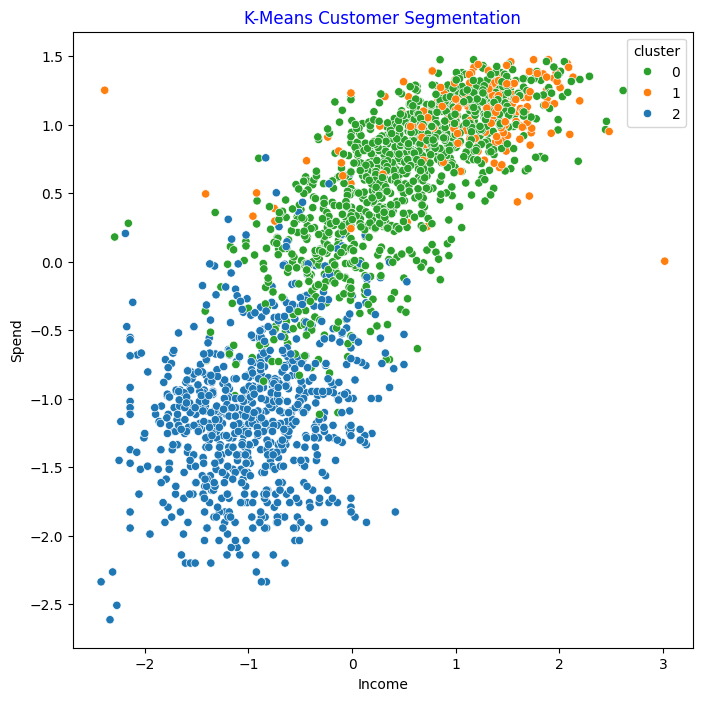

In [35]:
## Biểu diễn trực quan
plt.figure(figsize = (8, 8))
sns.scatterplot(
    x=data['Income'],
    y=data['Total_Spend'],
    hue=data['cluster'],palette=pal
)
plt.xlabel('Income')
plt.ylabel('Spend')
plt.title("K-Means Customer Segmentation", color = "blue")
plt.show()

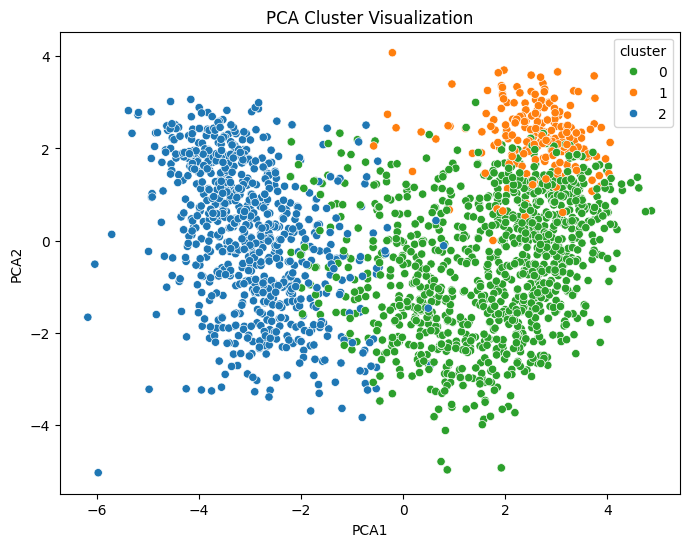

In [36]:
pca=PCA(n_components=2)
pca.fit(data)
PCA_ds=pd.DataFrame(pca.transform(data),columns=(['col1','col2']))

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=PCA_ds['col1'],
    y=PCA_ds['col2'],
    hue=data['cluster'],
    palette=pal
)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title('PCA Cluster Visualization')
plt.show()